## Objective
### Forecasting Google Trends Using VAR and SARIMA Models
- Introduction: 
This project analyzes the relationship between Bitcoin search interest and the term "Crypto Crash" using Google Trends data. 

- The goal is to understand whether changes in one search trend can help predict movements in the other, so this project applies time series forecasting techniques such as VAR and SARIMA models.

The Project includes: 
- collect and analyze Google Trends data using the pytrends library.
- checking stationarity and integration order of the time series.
- performing Granger causality tests.
- buiding VAR and SARIMA forecasting models.
- generating out-of-sample forecasts.
- comparing model performance using RMSE and MAE metrics.

- The results will help determine whether multivariate (VAR) or univariate (SARIMA) models better capture and predict Google search behavior in the cryptocurrency market.
 



### Import Libraries

In [14]:
!pip install pytrends

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pytrends.request import TrendReq
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.api import VAR
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_squared_error, mean_absolute_error

Defaulting to user installation because normal site-packages is not writeable


## Data Loading

In [16]:
from pytrends.request import TrendReq

pytrends = TrendReq()

kw_list = ["Bitcoin", "Crypto crash"]

pytrends.build_payload(kw_list,
                       timeframe='2021-01-01 2026-01-01',
                       geo='')

data = pytrends.interest_over_time()
data = data.drop(columns=['isPartial'])

# Save CSV 
data.to_csv("bitcoin_crypto_trends.csv", index=True)

data.head()

,Bitcoin,Crypto crash
date,,
2020-12-27,52,0
2021-01-03,86,0
2021-01-10,83,0
2021-01-17,53,0
2021-01-24,50,0


### Data Interpretation
- The dataset was collected using the pytrends library, which provides Google Trends data representing relative search interest over time. The analysis includes two keywords: “Bitcoin” and “Crypto crash”, covering the period from 2021 to 2026 at a global level.
- The values range between 0 and 100, where 100 represents the peak popularity of a search term within the selected timeframe. From the preview of the dataset, it can be observed that the “Bitcoin” series shows relatively continuous variation over time, reflecting general interest in the cryptocurrency market.
- The “Crypto crash” series contains many zero values with occasional spikes, indicating that searches related to market crashes occur irregularly and are concentrated around specific events. This suggests that “Crypto crash” captures sudden panic or crisis-driven behavior rather than consistent search activity.
- Additionally, the dataset is indexed by time and appears to follow a weekly frequency, which is typical for Google Trends data over long time horizons.

In [17]:
print(data.index[:10])
print(data.index.to_series().diff().value_counts())

DatetimeIndex(['2020-12-27', '2021-01-03', '2021-01-10', '2021-01-17',
               '2021-01-24', '2021-01-31', '2021-02-07', '2021-02-14',
               '2021-02-21', '2021-02-28'],
              dtype='datetime64[s]', name='date', freq=None)
date
7 days    261
Name: count, dtype: int64


## Initial Inspection

In [19]:
data = pd.read_csv("bitcoin_crypto_trends.csv", index_col=0, parse_dates=True)
data.head()


,Bitcoin,Crypto crash
date,,
2020-12-27,52,0
2021-01-03,86,0
2021-01-10,83,0
2021-01-17,53,0
2021-01-24,50,0


### Data Loading and Initial Inspection
The dataset was successfully loaded from the saved CSV file. The preview confirms that both variables are present and correctly indexed by date. This ensures the data is ready for further analysis.

## Stationary Test (Augmented Dickey-Fuller Test)

In [20]:
from statsmodels.tsa.stattools import adfuller

for col in data.columns:
    result = adfuller(data[col])
    print(f"Results for {col}")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("----------------------")

Results for Bitcoin
ADF Statistic: -3.3406774826131818
p-value: 0.01315525866691327
----------------------
Results for Crypto crash
ADF Statistic: -6.0025995800449214
p-value: 1.643783188431306e-07
----------------------


### Stationarity Test (Augmented Dickey-Fuller Test):

#### Hypothesis:
- null hypothesis (H₀): The time series is non-stationary (has a unit root).
- Alternative hypothesis (H₁): The time series is stationary.

#### Result and Interpretation:
- The Augmented Dickey-Fuller (ADF) test results indicate that both “Bitcoin” and “Crypto crash” series are stationary, as their p-values are below the 0.05 significance level.
- In particular, the p-value for “crypto crash” is extremely close to zero, which provides strong statistical evidence against the presence of a unit root. This confirms that the series is highly stationary.
- Therefore, the null hypothesis of non-stationarity is rejected for both variables, and the original series can be directly used for further analysis without applying differencing.

### Verification

In [21]:
print(data.columns)

Index(['Bitcoin', 'Crypto crash'], dtype='str')


In [22]:
print(data.info())

<class 'pandas.DataFrame'>
DatetimeIndex: 262 entries, 2020-12-27 to 2025-12-28
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Bitcoin       262 non-null    int64
 1   Crypto crash  262 non-null    int64
dtypes: int64(2)
memory usage: 6.1 KB
None


### Data Structure Verification
- The structure of the dataset was verified using the info() function. The output confirms that the date variable is correctly set as a DateTime index, which ensures that it is treated as a time reference rather than a variable in the analysis.
- The dataset contains two numerical variables, “Bitcoin” and “Crypto crash”, both of which have complete observations with no missing values and that means The data types are appropriate for time series analysis.
- This confirms that the dataset is properly formatted and suitable for applying statistical tests such as the Augmented Dickey-Fuller (ADF) test and further modeling techniques.

## Granger Causality Test
### Hypotheses
**Test 1: Bitcoin → Crypto crash**
- H₀: The first variable does NOT Granger-cause the second variable.
- H₁: The first variable DOES Granger-cause the second variable.
**Test 2: Crypto crash → Bitcoin**
- H₀: “crypto crash” does not Granger-cause Bitcoin
- H₁: “crypto crash” Granger-causes Bitcoin


In [23]:
from statsmodels.tsa.stattools import grangercausalitytests

grangercausalitytests(data[['Bitcoin', 'Crypto crash']], maxlag=5)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=5.5809  , p=0.0189  , df_denom=258, df_num=1
ssr based chi2 test:   chi2=5.6458  , p=0.0175  , df=1
likelihood ratio test: chi2=5.5856  , p=0.0181  , df=1
parameter F test:         F=5.5809  , p=0.0189  , df_denom=258, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=3.4890  , p=0.0320  , df_denom=255, df_num=2
ssr based chi2 test:   chi2=7.1147  , p=0.0285  , df=2
likelihood ratio test: chi2=7.0191  , p=0.0299  , df=2
parameter F test:         F=3.4890  , p=0.0320  , df_denom=255, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.3856  , p=0.2477  , df_denom=252, df_num=3
ssr based chi2 test:   chi2=4.2721  , p=0.2335  , df=3
likelihood ratio test: chi2=4.2373  , p=0.2370  , df=3
parameter F test:         F=1.3856  , p=0.2477  , df_denom=252, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=2.9229  , p=0.0218  

{np.int64(1): ({'ssr_ftest': (np.float64(5.580911602862954),
    np.float64(0.01890009537385209),
    np.float64(258.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(5.645805923826476),
    np.float64(0.017497172168369542),
    np.int64(1)),
   'lrtest': (np.float64(5.585609017026854),
    np.float64(0.018108635489356883),
    np.int64(1)),
   'params_ftest': (np.float64(5.580911602863031),
    np.float64(0.01890009537385126),
    np.float64(258.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(3.4889624277784046),
    np.float64(0.03199808908714054),
    np.float64(255.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(7.114746911548118),
    np.float64(0.028513618726922586),
    np.int64(2)),
   'lrtest': (np.float64(7.019141681866813),
    np.float64(0.029909747722383532),
    np.int64(2)),
   'params_ftest': (np.float64(3.488962427778436),
    np.float64(0.03199808908713956),
    np.float64(255.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
 

### Interpretation of Granger Causality Test:
#### Test 1:
- The Granger Causality Test was conducted to determine whether Bitcoin can predict Crypto Crash events.
- The null hypothesis states that Bitcoin does not Granger-cause Crypto Crash. 
- The results indicate statistically significant causality at lag lengths 1, 2, 4, and 5, the p-values obtained from the SSR-based F-test, Chi-square test, Likelihood Ratio test, and Parameter F-test are all below the 5% significance level. Therefore, the null hypothesis is rejected for these lags. This indicates that past Bitcoin values contain statistically significant information that helps predict future Crypto Crash movements.
- However, for lag 3, the p-values exceed 0.05, so the null hypothesis cannot be rejected at that lag. Overall, the evidence suggests the existence of Granger causality from Bitcoin to Crypto Crash, particularly at lag lengths 1, 2, 4, and 5.

## Reverse Causality 

In [24]:
grangercausalitytests(data[['Crypto crash', 'Bitcoin']], maxlag=5)



Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0749  , p=0.7846  , df_denom=258, df_num=1
ssr based chi2 test:   chi2=0.0757  , p=0.7832  , df=1
likelihood ratio test: chi2=0.0757  , p=0.7832  , df=1
parameter F test:         F=0.0749  , p=0.7846  , df_denom=258, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.0336  , p=0.9670  , df_denom=255, df_num=2
ssr based chi2 test:   chi2=0.0685  , p=0.9663  , df=2
likelihood ratio test: chi2=0.0685  , p=0.9663  , df=2
parameter F test:         F=0.0336  , p=0.9670  , df_denom=255, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.0788  , p=0.9714  , df_denom=252, df_num=3
ssr based chi2 test:   chi2=0.2430  , p=0.9704  , df=3
likelihood ratio test: chi2=0.2429  , p=0.9704  , df=3
parameter F test:         F=0.0788  , p=0.9714  , df_denom=252, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.8001  , p=0.5261  

{np.int64(1): ({'ssr_ftest': (np.float64(0.07486886496648108),
    np.float64(0.7845942334129135),
    np.float64(258.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.07573943316376575),
    np.float64(0.783156455187072),
    np.int64(1)),
   'lrtest': (np.float64(0.07572844589913075),
    np.float64(0.783171791076221),
    np.int64(1)),
   'params_ftest': (np.float64(0.07486886496646197),
    np.float64(0.7845942334129404),
    np.float64(258.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(0.033591633718451745),
    np.float64(0.9669705786244722),
    np.float64(255.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(0.06850058640625455),
    np.float64(0.9663296086332851),
    np.int64(2)),
   'lrtest': (np.float64(0.06849156427892922),
    np.float64(0.966333967817501),
    np.int64(2)),
   'params_ftest': (np.float64(0.03359163371846096),
    np.float64(0.9669705786244633),
    np.float64(255.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],


### Interpretation of Reverse Causality Test
- A reverse Granger Causality Test was conducted to examine whether Crypto Crash events can predict Bitcoin movements.
-  The null hypothesis states that Crypto Crash does not Granger-cause Bitcoin. The results show that the p-values for all lag lengths (1–5) are greater than the 5% significance level.
- Therefore, the null hypothesis cannot be rejected. This indicates that past Crypto Crash values do not provide statistically significant information for predicting future Bitcoin movements.
- There is no evidence of Granger causality running from Crypto Crash to Bitcoin.

## VAR Model Specification and Lag Selection

In [25]:
from statsmodels.tsa.api import VAR

model = VAR(data)

lag_order_results = model.select_order(maxlags=10)
print(lag_order_results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       0.8902      0.9183       2.436      0.9015
1      -0.2037    -0.1196*      0.8157    -0.1698*
2      -0.1853    -0.04521      0.8309     -0.1289
3      -0.1645     0.03158      0.8483    -0.08561
4      -0.1791     0.07297      0.8360    -0.07769
5     -0.2342*     0.07393     0.7913*     -0.1102
6      -0.2209      0.1432      0.8019    -0.07441
7      -0.2261      0.1941      0.7979    -0.05703
8      -0.1974      0.2788      0.8212   -0.005744
9      -0.1701      0.3621      0.8440     0.04400
10     -0.1563      0.4319      0.8559     0.08036
--------------------------------------------------


C:\Users\getde\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


### Interpretation of VAR and Lag Selection
- To determine the optimal number of lags for the VAR model, several information criteria were used, including the Akaike Information Criterion (AIC), Bayesian Information Criterion (BIC), Final Prediction Error (FPE), and Hannan-Quinn Information Criterion (HQIC).
- The results indicate that AIC and FPE suggest using 5 lags, while BIC and HQIC point to a shorter lag length of 1. Since AIC is generally preferred in time series analysis for its ability to capture more detailed dynamic relationships, the model with 5 lags was chosen for further analysis.
- Moreover, selecting 5 lags is consistent with earlier Granger causality results, where stronger and more significant relationships were observed at higher lag values.

## VAR Model Estimation

In [26]:
var_model = model.fit(5)
print(var_model.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 04, Jun, 2026
Time:                     21:19:33
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   0.168700
Nobs:                     257.000    HQIC:                -0.0129334
Log likelihood:          -689.973    FPE:                   0.873710
AIC:                    -0.135112    Det(Omega_mle):        0.803459
--------------------------------------------------------------------
Results for equation Bitcoin
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                   3.920600         1.340642            2.924           0.003
L1.Bitcoin              0.730872         0.071185           10.267           0.000
L1.Crypto crash        -6.048903         4.038316 

### Interpretation of VAR Model Estimation
- The VAR model with 5 lags was used to study the relationship between Bitcoin and “crypto crash” searches.
- The results show that Bitcoin is mainly influenced by its own past values, indicating a strong persistence over time. In addition, “crypto crash” has a noticeable impact on Bitcoin, but only at certain lags, suggesting that this effect appears with some delay.
- Overall, Bitcoin behavior is mostly driven by its own trend, with some delayed influence from panic-related searches.

### Importance of Stationarity in VAR Modeling
- Stationarity is important when applying VAR models because it ensures that the statistical properties of the series, such as mean and variance, remain constant over time. This allows for reliable estimation and valid inference.
- Since both series were found to be stationary, the VAR model can be applied directly without transformation.

### Importance of Granger Causality Test in VAR Modeling
- Granger causality is important in VAR models because it helps identify whether one variable contains useful information for predicting another.
- In this analysis, Bitcoin was found to Granger-cause “crypto crash”, meaning that past Bitcoin search activity helps explain future changes in panic-related searches.
- This confirms that there is a meaningful dynamic relationship between the two variables, which justifies the use of a VAR model to capture their interaction.

### Fitted vs Actual Values
- The fitted values follow the actual data reasonably well, indicating that the VAR model is able to capture the main patterns in both series. Some differences remain, especially during sudden spikes, which is expected in volatile search data.

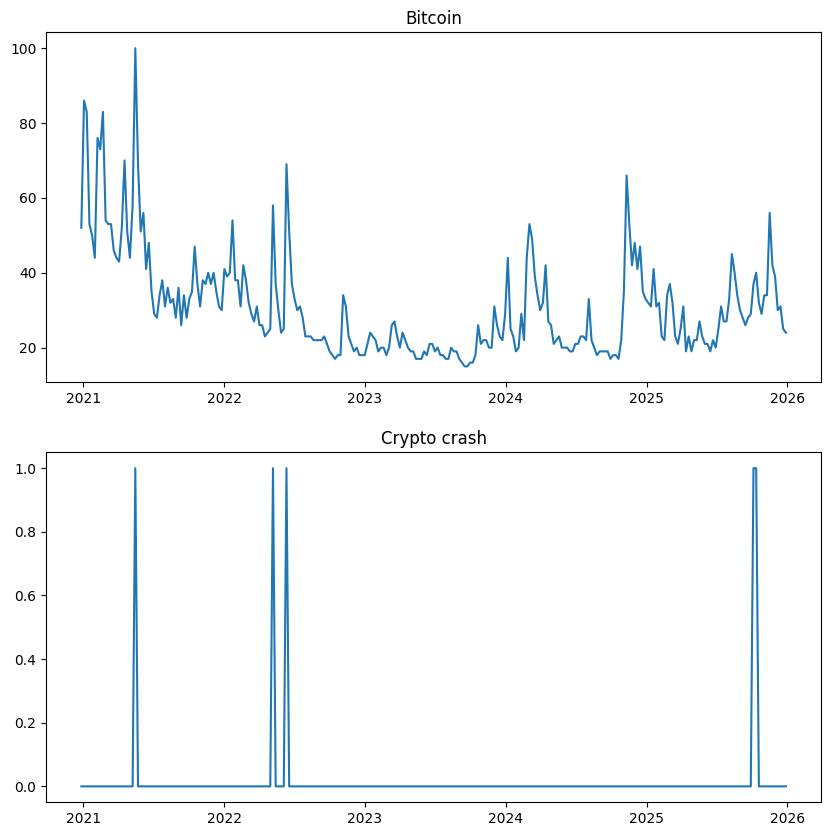

In [29]:
import matplotlib.pyplot as plt

var_model.plot()
plt.show()

### Interpretation: Bitcoin Plot
- This plot shows significant Volatility over the observed period from 2021 to 2026. In early yeras the series exhibits large fluctuations with values reaching peaks close to 100, that means periods of high market uncertainty and rapid price changes.
- From 2022 to 2023, the series enters a relatively stable phase, with values declining and fluctuating within a lower range (around 15–30). This suggests a period of reduced volatility and possibly market correction.
- From 2024 onwards, the Bitcoin series shows renewed fluctuations, with several sharp increases and decreases, though not as extreme as in earlier periods. This indicates that while volatility persists, the magnitude of fluctuations becomes more moderate over time.

### Interpretation: Crypto Crash Plot
- The crypto crash plot represents a binary variable indicating periods of significant market downturns (value = 1) and normal market conditions (value = 0).
- The graph shows that crash events are relatively rare and occur at specific points in time. Notable spikes are observed around 2021, 2022, and near 2026, suggesting that extreme negative movements in the cryptocurrency market are intermittent rather than continuous.
- These isolated spikes indicate that market crashes are sudden and short-lived events rather than prolonged periods of decline. This behavior is typical of financial markets, where extreme shocks occur infrequently but have significant impact.

## Residual Plots

array([<Axes: xlabel='date'>, <Axes: xlabel='date'>], dtype=object)

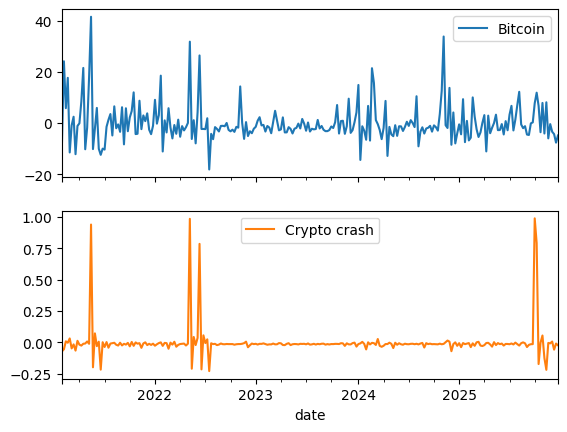

In [30]:
residuals = var_model.resid
residuals.plot(subplots=True)

### Residual Analysis
- The residual plots for both Bitcoin and “crypto crash” fluctuate around zero without showing any clear pattern or trend. This indicates that the model has successfully captured the underlying structure of the data.
- Although some spikes are present, especially in the “crypto crash” series, they are isolated and do not form any systematic pattern. This is expected given the nature of sudden panic-related searches.
- Overall, the residuals appear to behave like white noise, suggesting that the VAR model is well specified and provides a good fit to the data.

## ACF and PACF of Residuals

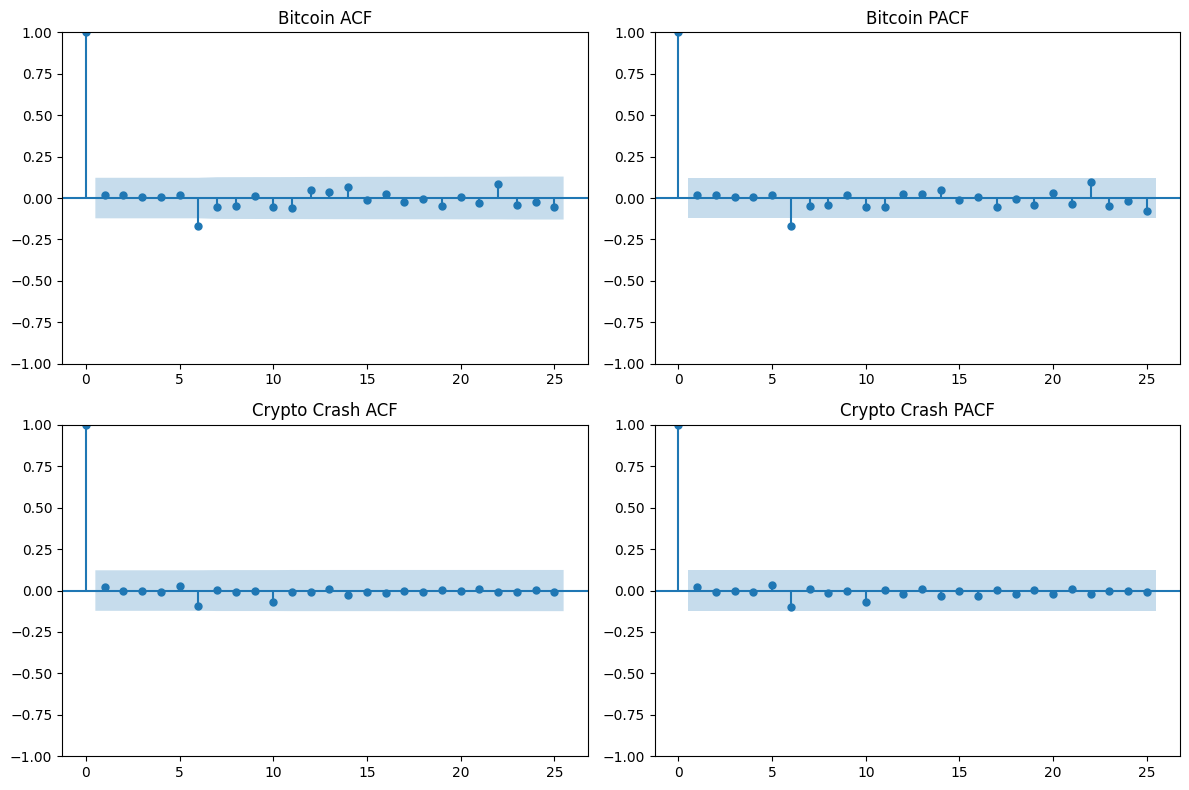

In [40]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

plot_acf(residuals['Bitcoin'], ax=ax[0,0])
ax[0,0].set_title('Bitcoin ACF')

plot_pacf(residuals['Bitcoin'], ax=ax[0,1])
ax[0,1].set_title('Bitcoin PACF')

plot_acf(residuals['Crypto crash'], ax=ax[1,0])
ax[1,0].set_title('Crypto Crash ACF')

plot_pacf(residuals['Crypto crash'], ax=ax[1,1])
ax[1,1].set_title('Crypto Crash PACF')

plt.tight_layout()
plt.show()

### Interpretation of ACF and PACF of Residuals
- The ACF and PACF plots for both Bitcoin and “crypto crash” residuals show that most autocorrelation values lie within the confidence bounds. This indicates that there is no significant autocorrelation remaining in the residuals.
- In simple terms, the residuals behave like white noise, meaning that the model has successfully captured the underlying patterns in the data.
-This confirms that the VAR model is well specified and provides a reliable representation of the relationship between the variables.

## Residual Autocorrelation Test
- To check whether the residuals are free from autocorrelation, the Ljung-Box test was applied. The results indicate that there is no significant autocorrelation in the residuals.
- This suggests that the VAR model adequately captures the dynamic relationships between the variables and is correctly specified.

In [38]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Bitcoin residuals
acorr_ljungbox(residuals['Bitcoin'], lags=[10], return_df=True)

# Crypto crash residuals
acorr_ljungbox(residuals['Crypto crash'], lags=[10], return_df=True)

,lb_stat,lb_pvalue
10,4.133561,0.941121


### Interpretation of Residual Autocorrelation Test
- The Ljung-Box test was applied to examine whether the residuals exhibit autocorrelation. The results show a high p-value (0.94), which is well above the 5% significance level. 
- This indicates that there is no significant autocorrelation in the residuals, meaning that the errors behave like white noise. Therefore, the VAR model is well specified and effectively captures the dynamics between Bitcoin and “crypto crash”.